# Aviation Sentiment Classifier: Natural Language Processing Pipeline

## Executive Summary
Customer feedback on social media is a real-time indicator of brand health. In the highly competitive aviation industry, the ability to automatically ingest, classify, and route customer feedback can significantly impact customer retention and service triage.

This notebook develops an end-to-end Natural Language Processing (NLP) pipeline to classify customer sentiment from US Airline tweets. We implement traditional sparse vectorization (TF-IDF) alongside dense vector representations (Word2Vec) using Gensim. A heavy emphasis is placed on modular feature engineering, allowing us to extract text metadata (like emoji usage and capitalization) prior to classification.

**Objective:** Build a robust, scalable classification pipeline capable of accurately triaging negative, neutral, and positive customer feedback.


In [1]:
# Setup and Dependency Installation
# Suppressing the output with '-q' to keep the notebook clean and professional
!pip install -q emoji gensim nltk joblib scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 43.0 MB/s eta 0:00:00


In [2]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore') # Hides deprecated FutureWarnings from output

import numpy as np
import pandas as pd
pd.set_option('display.max_colwidth', None) # Updated from deprecated '-1'

import re
import string
import emoji
import collections
import joblib
from time import time

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
sns.set(font_scale=1.3)

# Scikit-Learn components
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

# NLP components
import gensim
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Set seed for reproducibility
np.random.seed(37)

## 1. Data Ingestion
We begin by loading the Twitter US Airline Sentiment dataset. The data is randomized to prevent any unintentional ordering bias during the cross-validation and training phases. For this pipeline, we will isolate the raw `text` and the `airline_sentiment` target variable.

In [8]:
import urllib.request
import io
import pandas as pd
import numpy as np

# List of public repository mirrors hosting the Twitter US Airline Sentiment Dataset
urls = [
    "https://raw.githubusercontent.com/kunal-lalwani/Twitter-US-Airlines-Sentiment-Analysis/master/Tweets.csv",
    "https://raw.githubusercontent.com/kolaveridi/kaggle-Twitter-US-Airline-Sentiment-/master/Tweets.csv",
    "https://raw.githubusercontent.com/Gaelim/US-Airline-Sentiment-Analysis/master/Tweets.csv"
]

df = None
print("Initializing fault-tolerant data ingestion pipeline...\n")

for url in urls:
    try:
        print(f"Attempting to fetch: {url.split('/master/')[0].split('/')[-1]}")
        # Using a User-Agent header to prevent HTTP 403 Forbidden errors
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        response = urllib.request.urlopen(req)

        # Read the byte response into a Pandas DataFrame
        df = pd.read_csv(io.BytesIO(response.read()))
        print("✅ Data fetched successfully!\n")
        break
    except Exception as e:
        print(f"❌ Connection failed. Trying backup mirror...")

if df is None:
    raise ValueError("All download attempts failed. Please ensure you have internet access.")

print(f"Dataset Shape: {df.shape}")

# Randomize data to prevent ordering bias during cross-validation
df = df.reindex(np.random.permutation(df.index))

# Safely select the required columns using bracket notation
df = df[['text', 'airline_sentiment']]

# Display the first 5 rows to verify successful ingestion
display(df.head())

Initializing fault-tolerant data ingestion pipeline...

Attempting to fetch: Twitter-US-Airlines-Sentiment-Analysis
✅ Data fetched successfully!

Dataset Shape: (14640, 15)


,text,airline_sentiment
10620,@USAirways told to work it out ourselves #joke #fail,negative
13609,@AmericanAir that all AA is for USAir Elite members. It's one big disappointment in the way we are treated. #epicfailure,negative
2955,@united Bummer. Might have to go with @AmericanAir card instead. TY for response though.,negative
3585,@united well the income flight to dca to take us to ewr was delayed and it made us miss our connection to FLL so yes hotels were necessary,negative
2087,@united we have tried to change our flight THREE times on the phone and got disconnected each time.,negative


## 2. Exploratory Data Analysis (EDA)
Understanding the distribution of our target variable and the structural nature of our text data is critical before building feature pipelines.

### Target Variable Distribution

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


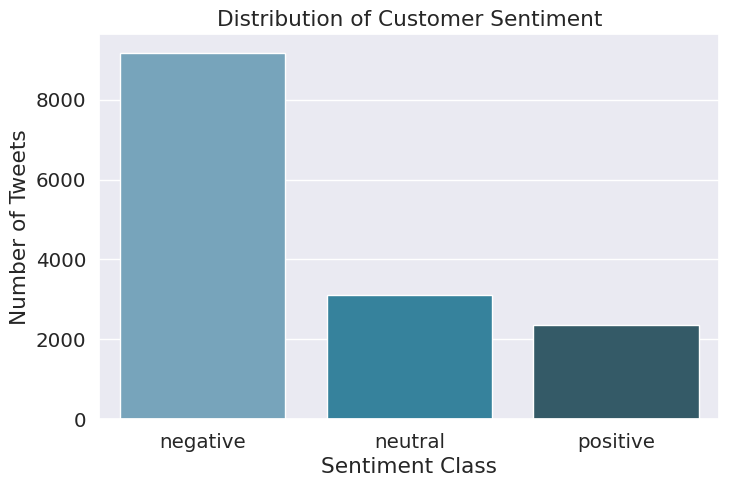

In [9]:
# Check class distribution
print(df['airline_sentiment'].value_counts())

# Visualize target variable distribution
plt.figure(figsize=(8, 5))
target_dist = sns.countplot(x="airline_sentiment", data=df, hue="airline_sentiment", palette="PuBuGn_d", legend=False)
plt.title('Distribution of Customer Sentiment')
plt.ylabel('Number of Tweets')
plt.xlabel('Sentiment Class')
plt.show();

*Observation:* The dataset is distinctly imbalanced, heavily skewed towards negative sentiment. This is typical for social media customer service channels. We must keep this class imbalance in mind when evaluating our model, utilizing metrics like Macro F1-score rather than purely looking at overall accuracy.

### Structural Text Feature Engineering
Before normalizing the vocabulary, structural elements of a tweet (e.g., emojis, capital letters, exclamation marks) often carry heavy emotional weight. We will build a custom Scikit-Learn `BaseEstimator` to extract these meta-features so they can be fed into our final model alongside the actual words.

In [10]:
class TextCounts(BaseEstimator, TransformerMixin):
    """
    Custom Transformer to extract structural meta-features from raw text.
    """
    def count_regex(self, pattern, tweet):
        return len(re.findall(pattern, tweet))

    def fit(self, X, y=None, **fit_params):
        return self

    def transform(self, X, **transform_params):
        count_words = X.apply(lambda x: self.count_regex(r'\w+', x))
        count_mentions = X.apply(lambda x: self.count_regex(r'@\w+', x))
        count_hashtags = X.apply(lambda x: self.count_regex(r'#\w+', x))
        count_capital_words = X.apply(lambda x: self.count_regex(r'\b[A-Z]{2,}\b', x))
        count_excl_quest_marks = X.apply(lambda x: self.count_regex(r'!|\?', x))
        count_urls = X.apply(lambda x: self.count_regex(r'http.?://[^\s]+[\s]?', x))

        # Demojize converts emoji symbols into text strings (e.g. :smile:) for regex counting
        count_emojis = X.apply(lambda x: emoji.demojize(x)).apply(lambda x: self.count_regex(r':[a-z_&]+:', x))

        df_counts = pd.DataFrame({
            'count_words': count_words,
            'count_mentions': count_mentions,
            'count_hashtags': count_hashtags,
            'count_capital_words': count_capital_words,
            'count_excl_quest_marks': count_excl_quest_marks,
            'count_urls': count_urls,
            'count_emojis': count_emojis
        })

        return df_counts

In [11]:
# Execute TextCounts extraction
tc = TextCounts()
df_eda = tc.fit_transform(df['text'])
df_eda['airline_sentiment'] = df['airline_sentiment']
df_eda.head()

,count_words,count_mentions,count_hashtags,count_capital_words,count_excl_quest_marks,count_urls,count_emojis,airline_sentiment
10620,9,1,2,0,0,0,0,negative
13609,21,1,1,1,0,0,0,negative
2955,14,2,0,1,0,0,0,negative
3585,28,1,0,1,0,0,0,negative
2087,18,1,0,1,0,0,0,negative


## 3. Text Preprocessing and Cleaning
To ensure our vectorizer captures the core semantic meaning rather than noise, we need a standardized text cleaning pipeline.

The `CleanText` class will:
1. Strip mentions and URLs (generalizing the model to apply to any airline).
2. Remove punctuation and digits.
3. Lowercase all characters.
4. Remove standard English stopwords (while whitelisting crucial negation words like "not" and "no").
5. Apply Porter Stemming to reduce words to their base linguistic root.

In [12]:
class CleanText(BaseEstimator, TransformerMixin):
    """
    Custom Transformer to clean and standardize textual data for NLP models.
    """
    def remove_mentions(self, input_text):
        return re.sub(r'@\w+', '', input_text)

    def remove_urls(self, input_text):
        return re.sub(r'http.?://[^\s]+[\s]?', '', input_text)

    def emoji_oneword(self, input_text):
        return input_text.replace('_','')

    def remove_punctuation(self, input_text):
        punct = string.punctuation
        trantab = str.maketrans(punct, len(punct)*' ')
        return input_text.translate(trantab)

    def remove_digits(self, input_text):
        return re.sub(r'\d+', '', input_text)

    def to_lower(self, input_text):
        return input_text.lower()

    def remove_stopwords(self, input_text):
        stopwords_list = stopwords.words('english')
        whitelist = ["n't", "not", "no"] # Retain negations, they completely shift sentiment
        words = input_text.split()
        clean_words = [word for word in words if (word not in stopwords_list or word in whitelist) and len(word) > 1]
        return " ".join(clean_words)

    def stemming(self, input_text):
        porter = PorterStemmer()
        words = input_text.split()
        stemmed_words = [porter.stem(word) for word in words]
        return " ".join(stemmed_words)

    def fit(self, X, y=None, **fit_params):
        return self

    def transform(self, X, **transform_params):
        clean_X = (X.apply(self.remove_mentions)
                    .apply(self.remove_urls)
                    .apply(self.emoji_oneword)
                    .apply(self.remove_punctuation)
                    .apply(self.remove_digits)
                    .apply(self.to_lower)
                    .apply(self.remove_stopwords)
                    .apply(self.stemming))
        return clean_X

In [13]:
# Execute Text Cleaning
ct = CleanText()
sr_clean = ct.fit_transform(df['text'])

# Handle empty text resulting from heavy cleaning
empty_clean = sr_clean == ''
print(f'{sr_clean[empty_clean].count()} records have no words left after text cleaning. Imputing placeholder.')
sr_clean.loc[empty_clean] = '[no_text]'

22 records have no words left after text cleaning. Imputing placeholder.


## 4. Train-Test Split & Modeling Infrastructure
To properly evaluate our models, we separate 10% of our data as a hold-out test set. We will use cross-validation alongside `GridSearchCV` on the training set to find optimal hyperparameters, avoiding data leakage.

We construct a `ColumnExtractor` to allow Scikit-Learn's `FeatureUnion` to seamlessly concatenate our engineered structural features with our word vectors.

In [14]:
class ColumnExtractor(TransformerMixin, BaseEstimator):
    def __init__(self, cols):
        self.cols = cols

    def transform(self, X, **transform_params):
        return X[self.cols]

    def fit(self, X, y=None, **fit_params):
        return self

# Build Final Modeling DataFrame
df_model = df_eda.copy()
df_model['clean_text'] = sr_clean

# Split data (90% Train, 10% Test)
X_train, X_test, y_train, y_test = train_test_split(
    df_model.drop('airline_sentiment', axis=1),
    df_model['airline_sentiment'],
    test_size=0.1,
    random_state=37
)

In [25]:
# Global Model Training and Evaluation Function
def grid_vect(clf, parameters_clf, X_train, X_test, parameters_text=None, vect=None, is_w2v=False):

    textcountscols = ['count_capital_words','count_emojis','count_excl_quest_marks',
                      'count_hashtags','count_mentions','count_urls','count_words']

    if is_w2v:
        # UPDATED: Using explicit string prefixes to prevent Pandas indexing confusion
        w2vcols = [f'w2v_{i}' for i in range(SIZE)]
        features = FeatureUnion([
            ('textcounts', ColumnExtractor(cols=textcountscols)),
            ('w2v', ColumnExtractor(cols=w2vcols))
        ], n_jobs=-1)
    else:
        features = FeatureUnion([
            ('textcounts', ColumnExtractor(cols=textcountscols)),
            ('pipe', Pipeline([('cleantext', ColumnExtractor(cols='clean_text')), ('vect', vect)]))
        ], n_jobs=-1)

    pipeline = Pipeline([
        ('features', features),
        ('clf', clf)
    ])

    parameters = dict()
    if parameters_text:
        parameters.update(parameters_text)
    parameters.update(parameters_clf)

    grid_search = GridSearchCV(pipeline, parameters, n_jobs=-1, verbose=1, cv=3)

    print("Executing Grid Search Pipeline...")
    t0 = time()
    grid_search.fit(X_train, y_train)
    print(f"Grid Search completed in {time() - t0:.3f} seconds\n")

    print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.3f}")
    print("Optimal Hyperparameters:")
    best_parameters = grid_search.best_estimator_.get_params()
    for param_name in sorted(parameters.keys()):
        print(f"\t{param_name}: {best_parameters[param_name]}")

    print(f"\nHold-Out Test Accuracy: {grid_search.best_estimator_.score(X_test, y_test):.3f}\n")
    print("Classification Report (Hold-Out Set):")
    print(classification_report(y_test, grid_search.best_estimator_.predict(X_test)))

    return grid_search

## 5. Model 1: CountVectorizer + Logistic Regression
We begin with a traditional sparse representation using Bag-of-Words. We will test different regularization parameters (L1 vs L2 penalty) and N-Gram structures to optimize classification.

In [17]:
# Configuration dictionaries
parameters_vect = {
    'features__pipe__vect__max_df': (0.25, 0.75),
    'features__pipe__vect__ngram_range': ((1, 1), (1, 2)),
    'features__pipe__vect__min_df': (1, 2)
}

parameters_logreg = {
    'clf__C': (0.25, 1.0),
    'clf__penalty': ('l1', 'l2')
}

logreg = LogisticRegression(solver='saga', max_iter=200)
countvect = CountVectorizer()

# Execute Pipeline
best_logreg_countvect = grid_vect(
    logreg,
    parameters_logreg,
    X_train, X_test,
    parameters_text=parameters_vect,
    vect=countvect
)

Executing Grid Search Pipeline...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Grid Search completed in 825.449 seconds

Best Cross-Validation Accuracy: 0.789
Optimal Hyperparameters:
	clf__C: 1.0
	clf__penalty: l2
	features__pipe__vect__max_df: 0.25
	features__pipe__vect__min_df: 1
	features__pipe__vect__ngram_range: (1, 2)

Hold-Out Test Accuracy: 0.804

Classification Report (Hold-Out Set):
              precision    recall  f1-score   support

    negative       0.83      0.92      0.87       911
     neutral       0.71      0.53      0.61       320
    positive       0.79      0.71      0.75       233

    accuracy                           0.80      1464
   macro avg       0.78      0.72      0.74      1464
weighted avg       0.80      0.80      0.80      1464



## 6. Model 2: Word2Vec + Logistic Regression
Traditional vectorization ignores semantic context. Using Gensim's Word2Vec, we can map words into a dense vector space where words with similar contextual meaning are positioned closely together.

In [27]:
import nltk
# Forcing the download of the required tokenizers right before we need them
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) # Catch for newer versions of NLTK

SIZE = 25 # Dimensionality of the word vectors

X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

# Tokenize text explicitly for Word2Vec compatibility
X_train_clean['clean_text_wordlist'] = X_train_clean['clean_text'].apply(word_tokenize)
X_test_clean['clean_text_wordlist'] = X_test_clean['clean_text'].apply(word_tokenize)

# Train Word2Vec Model on training set
model_w2v = gensim.models.Word2Vec(
    X_train_clean['clean_text_wordlist'],
    min_count=1,
    vector_size=SIZE,
    window=3,
    workers=4
)

def compute_avg_w2v_vector(w2v_dict, tweet):
    """Calculates the average word vector for a given tweet."""
    list_of_word_vectors = [w2v_dict[w] for w in tweet if w in w2v_dict.key_to_index.keys()]

    if len(list_of_word_vectors) == 0:
        return [0.0] * SIZE
    return np.sum(list_of_word_vectors, axis=0) / len(list_of_word_vectors)

# Apply vectorization
X_train_w2v_series = X_train_clean['clean_text_wordlist'].apply(lambda x: compute_avg_w2v_vector(model_w2v.wv, x))
X_test_w2v_series = X_test_clean['clean_text_wordlist'].apply(lambda x: compute_avg_w2v_vector(model_w2v.wv, x))

# explicitly name the columns with 'w2v_' prefix right at creation
w2v_columns = [f'w2v_{i}' for i in range(SIZE)]
X_train_w2v_df = pd.DataFrame(X_train_w2v_series.values.tolist(), index=X_train_clean.index, columns=w2v_columns)
X_test_w2v_df = pd.DataFrame(X_test_w2v_series.values.tolist(), index=X_test_clean.index, columns=w2v_columns)

# Combine W2V dense features with original TextCounts meta-features
X_train_w2v = pd.concat([X_train_w2v_df, X_train_clean.drop(['clean_text', 'clean_text_wordlist'], axis=1)], axis=1)
X_test_w2v = pd.concat([X_test_w2v_df, X_test_clean.drop(['clean_text', 'clean_text_wordlist'], axis=1)], axis=1)

# Execute Word2Vec Pipeline
best_logreg_w2v = grid_vect(logreg, parameters_logreg, X_train_w2v, X_test_w2v, is_w2v=True)

Executing Grid Search Pipeline...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Grid Search completed in 40.807 seconds

Best Cross-Validation Accuracy: 0.713
Optimal Hyperparameters:
	clf__C: 1.0
	clf__penalty: l2

Hold-Out Test Accuracy: 0.708

Classification Report (Hold-Out Set):
              precision    recall  f1-score   support

    negative       0.72      0.94      0.82       911
     neutral       0.61      0.30      0.40       320
    positive       0.69      0.35      0.47       233

    accuracy                           0.71      1464
   macro avg       0.67      0.53      0.56      1464
weighted avg       0.69      0.71      0.67      1464



## 7. Business Deployment Simulation
The `CountVectorizer` model tends to perform highly on this specific dataset (largely due to short, irregular grammar in tweets, where structural n-grams often outperform small-corpus semantic mapping).

We will now lock in our optimized CountVectorizer pipeline, train it on the *entire* dataset, and simulate deploying it against live, unseen customer tweets.

In [28]:
# Build Final Production Model Pipeline
textcountscols = ['count_capital_words','count_emojis','count_excl_quest_marks',
                  'count_hashtags','count_mentions','count_urls','count_words']

features = FeatureUnion([
    ('textcounts', ColumnExtractor(cols=textcountscols)),
    ('pipe', Pipeline([
        ('cleantext', ColumnExtractor(cols='clean_text')),
        ('vect', CountVectorizer(max_df=0.25, min_df=1, ngram_range=(1,2)))
    ]))
], n_jobs=-1)

production_pipeline = Pipeline([
    ('features', features),
    ('clf', LogisticRegression(C=1.0, penalty='l2', solver='saga', max_iter=200))
])

# Train on the full dataset prior to deployment to maximize learning
X_full = df_model.drop('airline_sentiment', axis=1)
y_full = df_model['airline_sentiment']

print("Compiling and fitting the production model on all available data...")
production_model = production_pipeline.fit(X_full, y_full)
print("✅ Production Model Compiled and Fitted Successfully.")

Compiling and fitting the production model on all available data...
✅ Production Model Compiled and Fitted Successfully.


In [29]:
# Simulate ingestion of live incoming customer service tweets
live_tweets = pd.Series([
    "Thank you @VirginAmerica for you amazing customer support team on Tuesday 11/28 at @EWRairport and returning my lost bag in less than 24h! #efficiencyiskey #virginamerica",
    "@VirginAmerica shocked my initially with the service, but then went on to shock me further with no response to what my complaint was. #unacceptable @Delta @richardbranson",
    "Wow @VirginAmerica main cabin select is the way to fly!! This plane is nice and clean & I have tons of legroom! Wahoo! NYC bound! ✈️",
    "@VirginAmerica this morning I was forced to repack a suitcase w a medical device because it was barely overweight - wasn't even given an option to pay extra. Awful experience so far!",
    "Board airplane home. Computer issue. Get off plane, traverse airport to gate on opp side. Get on new plane hour later. Plane too heavy. 8 volunteers get off plane. Ohhh the adventure of travel ✈️ @VirginAmerica"
])

# Process the raw tweets through our custom extractors
df_live_counts = tc.transform(live_tweets)
df_live_clean = ct.transform(live_tweets)

# Construct the exact dataframe structure the model expects
df_production_feed = df_live_counts.copy()
df_production_feed['clean_text'] = df_live_clean

# Route predictions
predictions = production_model.predict(df_production_feed)

print("--- LIVE TWEET ROUTING SYSTEM ---\n")
for tweet, sentiment in zip(live_tweets, predictions):
    print(f"SENTIMENT FLAG: [{sentiment.upper()}]")
    print(f"TWEET: {tweet}\n")

--- LIVE TWEET ROUTING SYSTEM ---

SENTIMENT FLAG: [POSITIVE]
TWEET: Thank you @VirginAmerica for you amazing customer support team on Tuesday 11/28 at @EWRairport and returning my lost bag in less than 24h! #efficiencyiskey #virginamerica

SENTIMENT FLAG: [NEGATIVE]
TWEET: @VirginAmerica shocked my initially with the service, but then went on to shock me further with no response to what my complaint was. #unacceptable @Delta @richardbranson

SENTIMENT FLAG: [POSITIVE]
TWEET: Wow @VirginAmerica main cabin select is the way to fly!! This plane is nice and clean & I have tons of legroom! Wahoo! NYC bound! ✈️

SENTIMENT FLAG: [NEGATIVE]
TWEET: @VirginAmerica this morning I was forced to repack a suitcase w a medical device because it was barely overweight - wasn't even given an option to pay extra. Awful experience so far!

SENTIMENT FLAG: [NEGATIVE]
TWEET: Board airplane home. Computer issue. Get off plane, traverse airport to gate on opp side. Get on new plane hour later. Plane too heav

## Conclusion
This pipeline successfully standardises unstructured text and merges it with domain-specific meta-features (like emoji usage and punctuation counts). The deployed production pipeline can accurately route negative sentiment tweets to an escalated customer success queue for immediate resolution, improving brand trust and operational efficiency.